In [1]:
import boto3
import botocore
import functools
from IPython.core.display import display, HTML
from iterdub import iterdub as ib
from iterpop import iterpop as ip
import itertools as it
import json
import matplotlib
import matplotlib.pyplot as plt
import math
import numpy as np
import pandas as pd
from pandas.util import hash_pandas_object
import seaborn as sns
from teeplot import teeplot as tp


In [2]:
from dishpylib.pyanalysis import calc_loglikelihoods_by_num_sets
from dishpylib.pyanalysis import count_hands_with_k_or_more_sets
from dishpylib.pyanalysis import count_hands_without_k_or_more_sets
from dishpylib.pyanalysis import estimate_interpolation_complexity
from dishpylib.pyanalysis import calc_loglikelihoods_over_set_sizes
from dishpylib.pyhelpers import get_env_context
from dishpylib.pyhelpers import get_git_revision_hash
from dishpylib.pyhelpers import make_timestamp
from dishpylib.pyhelpers import NumpyEncoder
from dishpylib.pyhelpers import preprocess_competition_fitnesses
from dishpylib.pyhelpers import print_runtime


In [3]:
print_runtime()


context: ci
hostname: runnervmjbsos
interpreter: 3.10.12 (main, Mar  3 2026, 11:56:32) [GCC 11.4.0]
notebook name: 2025-09-12-phenotype_neutral
notebook path: /home/runner/work/oee4/oee4/binder/2025-09-12-phenotype_neutral.ipynb
revision: bdac574
timestamp: 2026-07-07T14:10:30Z00:00

IPython==7.16.1
packaging==26.2


<ipython-input-3-4d790cf6450f>:1: DeprecatedWarning: print_runtime is deprecated. use nbmetalog package instead
  print_runtime()


In [4]:
teeplot_subdir = "2025-09-12-phenotype_neutral"


In [5]:
import boto3
import botocore
import functools
import pandas as pd

from dishpylib.pyhelpers import fit_control_t_distns

@functools.lru_cache
def get_control_t_distns( bucket, endeavor, stint ):

    s3_handle = boto3.resource(
        's3',
        region_name="us-east-2",
        config=botocore.config.Config(
            signature_version=botocore.UNSIGNED,
        ),
    )
    bucket_handle = s3_handle.Bucket(bucket)

    control_competitions, = bucket_handle.objects.filter(
        Prefix=f'endeavor={endeavor}/control-competitions/stage=2+what=collated/stint={stint}/',
    )

    control_df = pd.read_csv(
        f's3://{bucket}/{control_competitions.key}',
    )

    return fit_control_t_distns(control_df[
        control_df["Root ID"] == 1
    ].copy())


In [6]:
import functools
from iterpop import iterpop as ip
from scipy import stats


def preprocess_competition_fitnesses(competitions_df, control_fits_df):
    # preprocess data
    @functools.lru_cache
    def h0_fit(series):
        return ip.popsingleton(
            control_fits_df[control_fits_df["Series"] == series].to_dict(
                orient="records",
            )
        )

    competitions_df["p"] = competitions_df.apply(
        lambda row: stats.t.cdf(
            row["Fitness Differential"],
            h0_fit(row["genome series"])["Fit Degrees of Freedom"],
            loc=h0_fit(row["genome series"])["Fit Loc"],
            scale=h0_fit(row["genome series"])["Fit Scale"],
        ),
        axis=1,
    )
    competitions_df["Is Less Fit"] = competitions_df["p"] < 1.0 / 40
    competitions_df["Is More Fit"] = competitions_df["p"] > (1.0 -  1.0 / 40)
    competitions_df["Is Neutral"] = ~(
        competitions_df["Is Less Fit"] | competitions_df["Is More Fit"]
    )
    competitions_df["Relative Fitness"] = competitions_df.apply(
        lambda row: (
            "Significantly Advantageous"
            if row["Is More Fit"]
            else (
                "Significantly Deleterious" if row["Is Less Fit"] else "Neutral"
            )
        ),
        axis=1,
    )

    return competitions_df


# get data


In [7]:
s3_handle = boto3.resource(
    's3',
    region_name="us-east-2",
    config=botocore.config.Config(
        signature_version=botocore.UNSIGNED,
    ),
)
bucket_handle = s3_handle.Bucket('prq49')

dfs = []
for stint in range(101):
    print(stint)
    try:
        series_profiles, = [
        x for x in bucket_handle.objects.filter(
                Prefix=f'endeavor=16/phenotype-neutral-nopout-competitions/stage=2+what=generated/stint={stint}/series=16005/a=coalescence_result',
            )
            if x.key.endswith(".csv")
        ]
    except ValueError:
        print(f"Skipping stint {stint} because no data")
        pass
    control_fits_df = get_control_t_distns('prq49', 16, stint)
    df = pd.read_csv(
        f's3://prq49/{series_profiles.key}',
    )
    df = df[df["Competition Series"] == 16005]
    df = df[df["genome morph"] != "wildtype"].copy()
    print(stint, len(df))
    df["Stint"] = stint
    dfdigest = '{:x}'.format( hash_pandas_object( df ).sum() )
    print(dfdigest)
    df = preprocess_competition_fitnesses(df, control_fits_df)
    dfs.append(df)


0
0 1
74b126a1660c69dc
1
1 1
1844cc6d27ed0374
2
2 1
56be8392abff86d7
3
3 1
-6ea5f0478324599b
4
4 1
1eeac093d95010aa
5
5 1
-3ffd8ed6fd0224c0
6
6 1
-3a72166feb2fba6e
7
7 1
1e183ca9f6fe89be
8
8 1
-591870c8402393a9
9
9 1
329f2d03a755d235
10
10 1
-7841af8d202970f0
11
11 1
-556b21894e5e7421
12
12 1
-4d51e5293c86c597
13
13 1
96950c8b24641f5
14
14 1
-345f1af040c5a0b9
15
15 1
3a04c8b04ad4cc47
16
16 1
60fa8967269b7462
17
17 1
35ea71049504b8aa
18
18 1
5fab6ff3113099f4
19
19 1
111e3fa2641d418b
20
20 1
-2b23527913805963
21
21 1
1af19f3bd55b8293
22
22 1
5b71392a677ccfb5
23
23 1
-39c2de268337a97c
24
24 1
-65f30507e6162e85
25
25 1
-7dc143aebc0cfe75
26
26 1
-26a612d1f96655ea
27
27 1
97dc6c9082cae36
28
28 1
-1bf5f117e67cbe62
29
29 1
40e36d892e484ccf
30
30 1
-5266be87148de22
31
31 1
-4435e5bb374ccb1e
32
32 1
5f6953d663b0d861
33
33 1
-280c4c265b520ae1
34
34 1
76e1e22851e53c86
35
35 1
4da85d780283e443
36
36 1
-4911864b76aa1f74
37
37 1
-7ddb00b8c16aad72
38
38 1
10ec2046db2ddb5e
39
39 1
-37e313d4cb88656e
40


In [8]:
df = pd.concat(dfs)
df


,Competition Stint,Competition Series,Competition Replicate,Competition Treatment,Treatment _,Treatment mut_sever,Treatment mut_freq,Treatment diversity,Treatment bucket,Competition Endeavor,...,genome series,genome stint,genome thread,genome variation,Stint,p,Is Less Fit,Is More Fit,Is Neutral,Relative Fitness
0,0,16005,0,bucket=prq49+diversity=0.50_series+mut_freq=1....,bucket=prq49+diversity=0.50_series+mut_freq=1....,1.0,1.0,0.50_series,prq49,16,...,16005,0,0,master,0,0.810182,False,False,True,Neutral
0,1,16005,0,bucket=prq49+diversity=0.50_series+mut_freq=1....,bucket=prq49+diversity=0.50_series+mut_freq=1....,1.0,1.0,0.50_series,prq49,16,...,16005,1,0,master,1,0.206666,False,False,True,Neutral
1,2,16005,0,bucket=prq49+diversity=0.50_series+mut_freq=1....,bucket=prq49+diversity=0.50_series+mut_freq=1....,1.0,1.0,0.50_series,prq49,16,...,16005,2,0,master,2,0.364233,False,False,True,Neutral
0,3,16005,0,bucket=prq49+diversity=0.50_series+mut_freq=1....,bucket=prq49+diversity=0.50_series+mut_freq=1....,1.0,1.0,0.50_series,prq49,16,...,16005,3,0,master,3,0.042926,False,False,True,Neutral
0,4,16005,0,bucket=prq49+diversity=0.50_series+mut_freq=1....,bucket=prq49+diversity=0.50_series+mut_freq=1....,1.0,1.0,0.50_series,prq49,16,...,16005,4,0,master,4,0.008159,True,False,False,Significantly Deleterious
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,96,16005,0,bucket=prq49+diversity=0.50_series+mut_freq=1....,bucket=prq49+diversity=0.50_series+mut_freq=1....,1.0,1.0,0.50_series,prq49,16,...,16005,96,0,master,96,0.097241,False,False,True,Neutral
0,97,16005,0,bucket=prq49+diversity=0.50_series+mut_freq=1....,bucket=prq49+diversity=0.50_series+mut_freq=1....,1.0,1.0,0.50_series,prq49,16,...,16005,97,0,master,97,0.001252,True,False,False,Significantly Deleterious
1,98,16005,0,bucket=prq49+diversity=0.50_series+mut_freq=1....,bucket=prq49+diversity=0.50_series+mut_freq=1....,1.0,1.0,0.50_series,prq49,16,...,16005,98,0,master,98,0.459078,False,False,True,Neutral
0,99,16005,0,bucket=prq49+diversity=0.50_series+mut_freq=1....,bucket=prq49+diversity=0.50_series+mut_freq=1....,1.0,1.0,0.50_series,prq49,16,...,16005,99,0,master,99,0.995782,False,True,False,Significantly Advantageous


<AxesSubplot:xlabel='Competition Stint', ylabel='Is More Fit'>

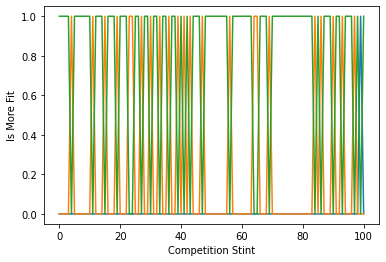

In [9]:
sns.lineplot(
    x=df["Competition Stint"],
    y=df["Is More Fit"],
)
sns.lineplot(
    x=df["Competition Stint"],
    y=df["Is Less Fit"],
)
sns.lineplot(
    x=df["Competition Stint"],
    y=df["Is Neutral"],
)
